In [1]:
import pandas as pd

In [2]:
customer_dataframe = pd.read_csv("../datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
customer_dataframe.shape

(7043, 21)

In [4]:
customer_dataframe.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
customer_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# what do this?

In [6]:
customer_dataframe.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
customer_dataframe.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
customer_dataframe["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

# what do this?

In [9]:
customer_dataframe["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [10]:
customer_dataframe.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
customer_dataframe["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
customer_dataframe["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [13]:
customer_dataframe["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

# create a crosstable with informacion of churn and contract

In [14]:
pd.crosstab(customer_dataframe["Contract"], customer_dataframe["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


# Group churn of dataframe and describe tenure on base churn 

In [15]:
customer_dataframe.groupby("Churn")
for nombre, grupo in customer_dataframe.groupby("Churn"):
    print(nombre)
    print(grupo[["tenure"]].head())

No
   tenure
0       1
1      34
3      45
6      22
7      10
Yes
    tenure
2        2
4        2
5        8
8       28
13      49


In [16]:
customer_dataframe.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [17]:
customer_dataframe.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [18]:
customer_dataframe.groupby("Churn")["gender"].describe()

,count,unique,top,freq
Churn,,,,
No,5174,2,Male,2625
Yes,1869,2,Female,939


In [19]:
pd.crosstab(
    customer_dataframe["gender"],
    customer_dataframe["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [20]:
customer_dataframe["TotalCharges"].dtype

dtype('O')

In [21]:
customer_dataframe["TotalCharges"].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object

In [22]:
customer_dataframe["TotalCharges"].sample(20)

5985    4368.95
3670      838.5
5294     5566.4
4811      193.6
6812     3778.1
4354     1192.3
2555     487.75
5375       50.8
791        5023
6490     525.55
4739      929.3
5378    4415.75
6817     1872.2
3762     749.25
369     8126.65
5615       20.2
2045    7455.45
674      2550.9
568      3527.6
2008     341.45
Name: TotalCharges, dtype: object

In [23]:
customer_dataframe[customer_dataframe["TotalCharges"] == " "].count()

customerID          11
gender              11
SeniorCitizen       11
Partner             11
Dependents          11
tenure              11
PhoneService        11
MultipleLines       11
InternetService     11
OnlineSecurity      11
OnlineBackup        11
DeviceProtection    11
TechSupport         11
StreamingTV         11
StreamingMovies     11
Contract            11
PaperlessBilling    11
PaymentMethod       11
MonthlyCharges      11
TotalCharges        11
Churn               11
dtype: int64

In [24]:
(customer_dataframe["TotalCharges"] == " ").sum()

11

In [25]:
customer_dataframe[customer_dataframe["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [26]:
customer_dataframe[customer_dataframe["TotalCharges"] == " "][
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


In [27]:
customer_dataframe["TotalCharges"] = pd.to_numeric(customer_dataframe["TotalCharges"], errors="coerce")

In [28]:
customer_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [29]:
customer_dataframe["TotalCharges"].isnull().sum()

11

In [30]:
customer_dataframe["TotalCharges"] = customer_dataframe["TotalCharges"].fillna(0)

In [31]:
customer_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [32]:
customer_dataframe.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [33]:
customer_dataframe.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [34]:
customer_dataframe.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [35]:
customer_dataframe.groupby("Churn")["TotalCharges"].mean()

Churn
No     2549.911442
Yes    1531.796094
Name: TotalCharges, dtype: float64

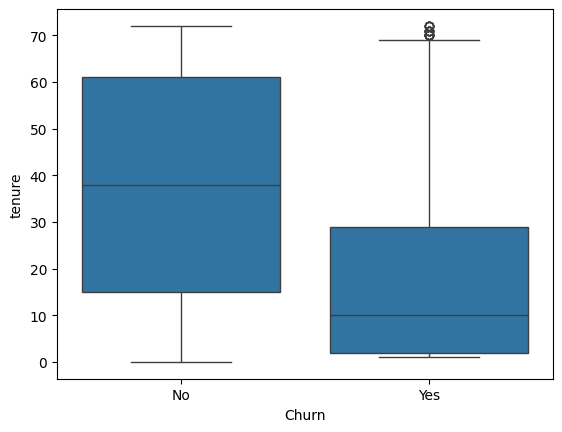

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=customer_dataframe,
    x="Churn",
    y="tenure"
)

plt.show()

In [37]:
pd.crosstab(
    customer_dataframe["Partner"],
    customer_dataframe["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


In [38]:
pd.crosstab(customer_dataframe["OnlineSecurity"],
           customer_dataframe["Churn"],
           normalize="index") *100

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [39]:
pd.crosstab(customer_dataframe["TechSupport"],
           customer_dataframe["Churn"],
           normalize="index") *100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [40]:
pd.crosstab(customer_dataframe["PaymentMethod"],
           customer_dataframe["Churn"],
           normalize="index")*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


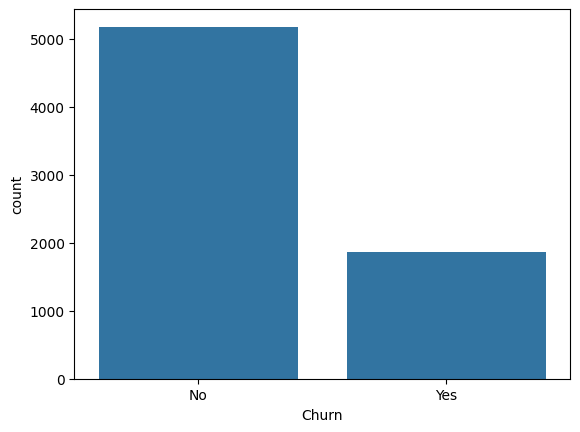

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=customer_dataframe, x="Churn")

plt.show()

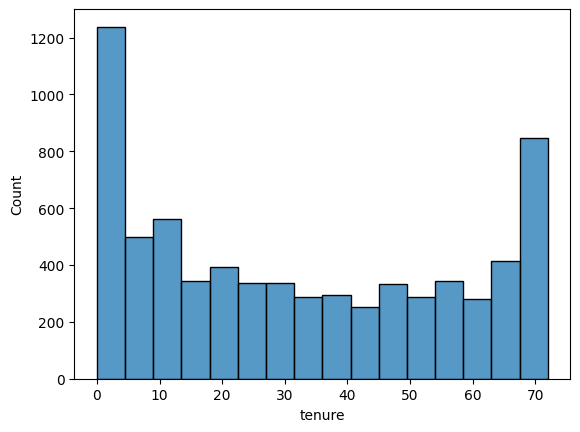

In [42]:
sns.histplot(customer_dataframe["tenure"])
plt.show()

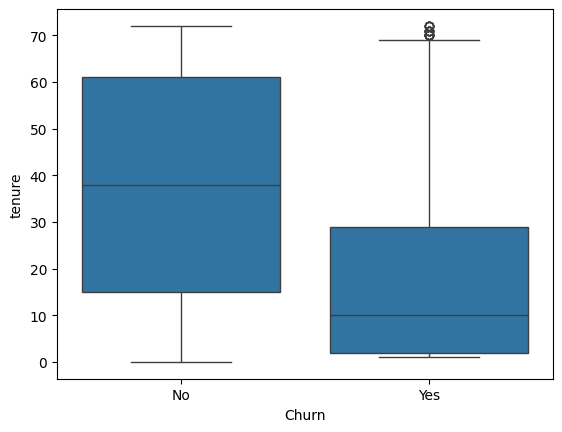

In [43]:
sns.boxplot(
    data=customer_dataframe,
    x="Churn",
    y="tenure"
)
plt.show()

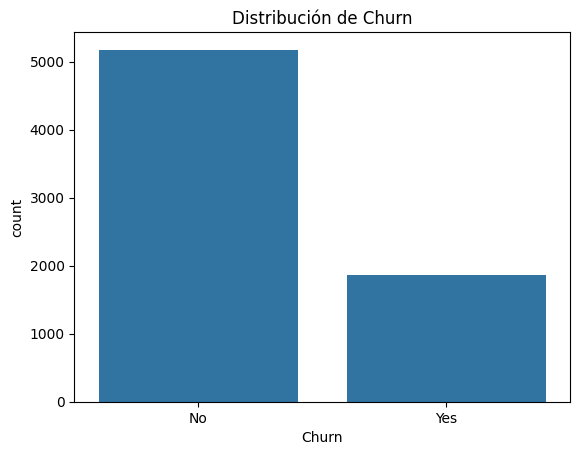

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=customer_dataframe, x="Churn")

plt.title("Distribución de Churn")
plt.show()

In [45]:
contract_churn = pd.crosstab(
    customer_dataframe["Contract"],
    customer_dataframe["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


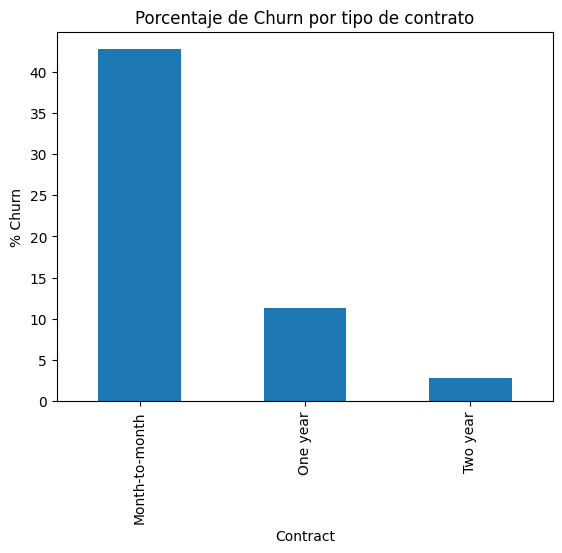

In [46]:
contract_churn["Yes"].plot(kind="bar")

plt.title("Porcentaje de Churn por tipo de contrato")
plt.ylabel("% Churn")
plt.show()

In [47]:
pd.crosstab(
    customer_dataframe["Contract"],
    customer_dataframe["OnlineSecurity"],
    normalize="index"
) * 100

OnlineSecurity,No,No internet service,Yes
Contract,,,
Month-to-month,67.896774,13.522581,18.580645
One year,37.813985,24.711473,37.474542
Two year,18.289086,37.640118,44.070796


In [48]:
customer_dataframe.groupby("Contract")["tenure"].mean()

Contract
Month-to-month    18.036645
One year          42.044807
Two year          56.735103
Name: tenure, dtype: float64

In [49]:
customer_dataframe.select_dtypes(include=["int64", "float64"]).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [50]:
customer_dataframe.select_dtypes(include=["int64", "float64"]).corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


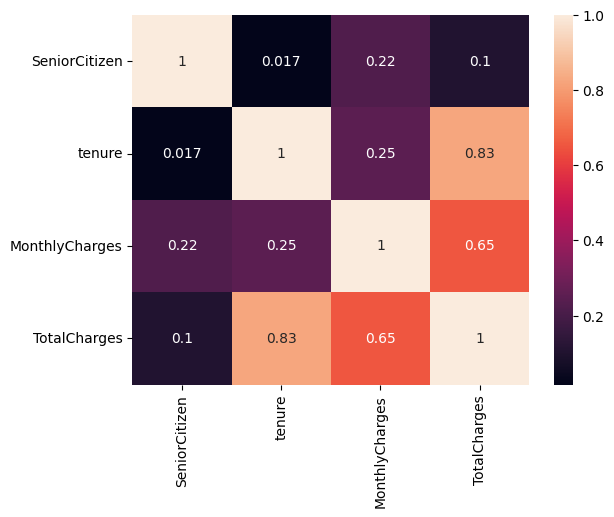

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = customer_dataframe.select_dtypes(
    include=["int64", "float64"]
).corr()

sns.heatmap(
    corr,
    annot=True
)

plt.show()

In [52]:
X = customer_dataframe.drop(["customerID", "Churn"], axis=1)
y = customer_dataframe["Churn"]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [53]:
for columna in X.select_dtypes(include="object").columns:
    print(f"{columna}: {X[columna].unique()}")
    print("-" * 50)

gender: ['Female' 'Male']
--------------------------------------------------
Partner: ['Yes' 'No']
--------------------------------------------------
Dependents: ['No' 'Yes']
--------------------------------------------------
PhoneService: ['No' 'Yes']
--------------------------------------------------
MultipleLines: ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService: ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity: ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup: ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection: ['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport: ['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV: ['No' 'Yes' 'No internet service']
--------------------------------------------------

In [54]:
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   gender_Male                            7043 non-null   int64  
 5   Partner_Yes                            7043 non-null   int64  
 6   Dependents_Yes                         7043 non-null   int64  
 7   PhoneService_Yes                       7043 non-null   int64  
 8   MultipleLines_No phone service         7043 non-null   int64  
 9   MultipleLines_Yes                      7043 non-null   int64  
 10  InternetService_Fiber optic            7043 non-null   int64  
 11  Inte

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(5634, 30)
(1409, 30)
(5634,)
(1409,)


In [56]:
print(y_train.value_counts(normalize=True))

print("-" * 30)

print(y_test.value_counts(normalize=True))

Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64
------------------------------
Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64


In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Columnas que se van a escalar
columnas_numericas = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# Copiamos los DataFrames
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Creamos el scaler
scaler = StandardScaler()

# Aprende la media y desviación SOLO del entrenamiento
scaler.fit(X_train[columnas_numericas])

# Transforma entrenamiento
X_train_scaled[columnas_numericas] = scaler.transform(X_train[columnas_numericas])

# Transforma prueba usando la misma media y desviación
X_test_scaled[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

# Creamos el modelo
model = LogisticRegression(random_state=42)

# Entrenamos
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [58]:
# ============================
# PREDICCIONES DEL MODELO
# ============================

# Predicciones (Yes / No)
y_pred = model.predict(X_test_scaled)

# Probabilidades de cada clase
y_proba = model.predict_proba(X_test_scaled)

# Probabilidad únicamente de Churn = Yes
probabilidad_churn = y_proba[:, 1]

# Mostrar algunos resultados
print("Predicciones:")
print(y_pred[:10])

print("\nProbabilidades:")
print(y_proba[:10])

print("\nProbabilidad de Churn:")

Predicciones:
['No' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No']

Probabilidades:
[[0.9535867  0.0464133 ]
 [0.31580675 0.68419325]
 [0.9396986  0.0603014 ]
 [0.60140726 0.39859274]
 [0.97816829 0.02183171]
 [0.39648774 0.60351226]
 [0.55412396 0.44587604]
 [0.87125708 0.12874292]
 [0.99709932 0.00290068]
 [0.60426945 0.39573055]]

Probabilidad de Churn:


In [59]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8062


In [60]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[927 108]
 [165 209]]


In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.85      0.90      0.87      1035
         Yes       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [62]:
coeficientes = pd.DataFrame({
    "Variable": X_train_scaled.columns,
    "Coeficiente": model.coef_[0]
})

coeficientes = coeficientes.sort_values(
    by="Coeficiente",
    ascending=False
)

print(coeficientes)

                                 Variable  Coeficiente
10            InternetService_Fiber optic     1.180666
3                            TotalCharges     0.527772
28         PaymentMethod_Electronic check     0.392775
21                        StreamingTV_Yes     0.374831
26                   PaperlessBilling_Yes     0.374218
23                    StreamingMovies_Yes     0.373193
9                       MultipleLines_Yes     0.361646
0                           SeniorCitizen     0.147911
29             PaymentMethod_Mailed check     0.081866
17                   DeviceProtection_Yes     0.033106
5                             Partner_Yes     0.022232
4                             gender_Male     0.020476
27  PaymentMethod_Credit card (automatic)    -0.020968
15                       OnlineBackup_Yes    -0.094768
22    StreamingMovies_No internet service    -0.172521
11                     InternetService_No    -0.172521
12     OnlineSecurity_No internet service    -0.172521
14       O

AUC: 0.8422


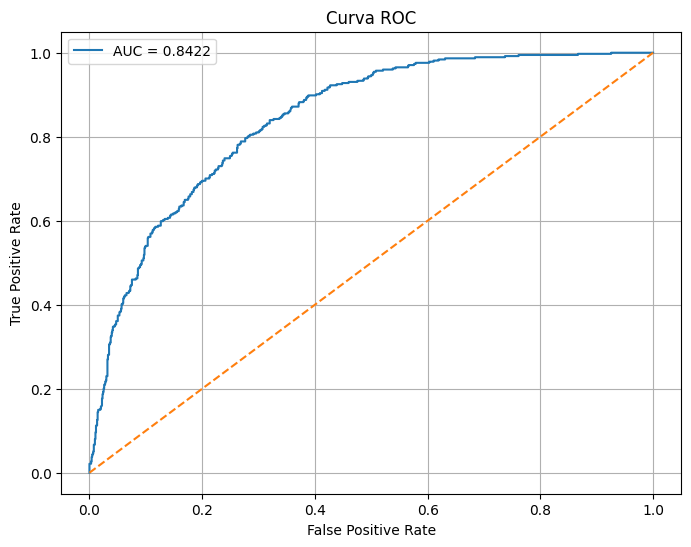

In [63]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilidades de churn
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba, pos_label="Yes")

# Calcular AUC
auc = roc_auc_score(y_test, y_proba)

print(f"AUC: {auc:.4f}")

# Graficar
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)
plt.show()

In [66]:
from sklearn.metrics import precision_score, recall_score, f1_score

resultados = []

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:

    y_pred = ["Yes" if p >= threshold else "No" for p in y_proba]

    resultados.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred, pos_label="Yes"),
        "Recall": recall_score(y_test, y_pred, pos_label="Yes"),
        "F1": f1_score(y_test, y_pred, pos_label="Yes")
    })

pd.DataFrame(resultados)

,Threshold,Precision,Recall,F1
0,0.2,0.467153,0.855615,0.604344
1,0.3,0.520221,0.756684,0.616558
2,0.4,0.569794,0.665775,0.614057
3,0.5,0.659306,0.558824,0.604920
4,0.6,0.717703,0.401070,0.514580
5,0.7,0.744681,0.187166,0.299145
